<a href="https://colab.research.google.com/github/rakshapanchariya03-rgb/Creation-of-Workforce-Insights-Dashboard-for-Employee-Skill-and-Analytics/blob/main/SQL_TASK_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Import the Python libraries required to create and query a SQL database inside Google Colab.

In [1]:
import sqlite3
import pandas as pd


Create an SQLite database connection. The database will be stored temporarily in memory while the Colab notebook is running.

In [2]:
conn = sqlite3.connect(":memory:")

print("Database connection created successfully.")


Database connection created successfully.


Create a table named sales containing transaction information such as month, region, product, sales representative, advertising spend, units sold, and revenue.

In [3]:
create_table = """
CREATE TABLE sales (
    sale_id INTEGER PRIMARY KEY,
    month TEXT,
    region TEXT,
    product TEXT,
    sales_rep TEXT,
    advertising_spend REAL,
    units_sold INTEGER,
    revenue REAL
);
"""

conn.execute(create_table)
conn.commit()

print("Sales table created successfully.")


Sales table created successfully.


 Insert the following sample sales transactions into the sales table.

In [4]:
sales_data = [
    (1, "Jan", "North", "Laptop", "Amit", 2000, 120, 12000),
    (2, "Feb", "South", "Phone", "Priya", 2500, 150, 14500),
    (3, "Mar", "East", "Laptop", "Rahul", 3000, 180, 17000),
    (4, "Apr", "West", "Tablet", "Neha", 2800, 170, 16500),
    (5, "May", "North", "Phone", "Amit", 3500, 210, 20000),
    (6, "Jun", "South", "Laptop", "Priya", 4000, 230, 22500),
    (7, "Jul", "East", "Tablet", "Rahul", 4200, 250, 24000),
    (8, "Aug", "West", "Phone", "Neha", 4500, 270, 26000),
    (9, "Sep", "North", "Laptop", "Amit", 4800, 290, 28000),
    (10, "Oct", "South", "Tablet", "Priya", 5000, 310, 30000),
    (11, "Nov", "East", "Phone", "Rahul", 5500, 340, 32500),
    (12, "Dec", "West", "Laptop", "Neha", 6000, 360, 35000)
]

insert_query = """
INSERT INTO sales
(sale_id, month, region, product, sales_rep,
 advertising_spend, units_sold, revenue)
VALUES (?, ?, ?, ?, ?, ?, ?, ?)
"""

conn.executemany(insert_query, sales_data)
conn.commit()

print("Data inserted successfully.")


Data inserted successfully.


 Retrieve all records from the sales table and display them in a readable format.

In [5]:
query = """
SELECT *
FROM sales;
"""

df = pd.read_sql_query(query, conn)

display(df)


,sale_id,month,region,product,sales_rep,advertising_spend,units_sold,revenue
0,1,Jan,North,Laptop,Amit,2000.0,120,12000.0
1,2,Feb,South,Phone,Priya,2500.0,150,14500.0
2,3,Mar,East,Laptop,Rahul,3000.0,180,17000.0
3,4,Apr,West,Tablet,Neha,2800.0,170,16500.0
4,5,May,North,Phone,Amit,3500.0,210,20000.0
5,6,Jun,South,Laptop,Priya,4000.0,230,22500.0
6,7,Jul,East,Tablet,Rahul,4200.0,250,24000.0
7,8,Aug,West,Phone,Neha,4500.0,270,26000.0
8,9,Sep,North,Laptop,Amit,4800.0,290,28000.0
9,10,Oct,South,Tablet,Priya,5000.0,310,30000.0


Display only the month, region, product, and revenue columns from the sales table.

In [6]:
query = """
SELECT
    month,
    region,
    product,
    revenue
FROM sales;
"""

pd.read_sql_query(query, conn)


,month,region,product,revenue
0,Jan,North,Laptop,12000.0
1,Feb,South,Phone,14500.0
2,Mar,East,Laptop,17000.0
3,Apr,West,Tablet,16500.0
4,May,North,Phone,20000.0
5,Jun,South,Laptop,22500.0
6,Jul,East,Tablet,24000.0
7,Aug,West,Phone,26000.0
8,Sep,North,Laptop,28000.0
9,Oct,South,Tablet,30000.0


Find all sales transactions where the revenue is greater than ₹25,000.

In [7]:
query = """
SELECT *
FROM sales
WHERE revenue > 25000;
"""

pd.read_sql_query(query, conn)


,sale_id,month,region,product,sales_rep,advertising_spend,units_sold,revenue
0,8,Aug,West,Phone,Neha,4500.0,270,26000.0
1,9,Sep,North,Laptop,Amit,4800.0,290,28000.0
2,10,Oct,South,Tablet,Priya,5000.0,310,30000.0
3,11,Nov,East,Phone,Rahul,5500.0,340,32500.0
4,12,Dec,West,Laptop,Neha,6000.0,360,35000.0


Retrieve all sales transactions from the North region.

In [8]:
query = """
SELECT *
FROM sales
WHERE region = 'North';
"""

pd.read_sql_query(query, conn)


,sale_id,month,region,product,sales_rep,advertising_spend,units_sold,revenue
0,1,Jan,North,Laptop,Amit,2000.0,120,12000.0
1,5,May,North,Phone,Amit,3500.0,210,20000.0
2,9,Sep,North,Laptop,Amit,4800.0,290,28000.0


Find all transactions where the region is North and revenue is greater than ₹15,000.

In [9]:
query = """
SELECT *
FROM sales
WHERE region = 'North'
  AND revenue > 15000;
"""

pd.read_sql_query(query, conn)


,sale_id,month,region,product,sales_rep,advertising_spend,units_sold,revenue
0,5,May,North,Phone,Amit,3500.0,210,20000.0
1,9,Sep,North,Laptop,Amit,4800.0,290,28000.0


Retrieve sales transactions from either the North or South regions.

In [10]:
query = """
SELECT *
FROM sales
WHERE region = 'North'
   OR region = 'South';
"""

pd.read_sql_query(query, conn)


,sale_id,month,region,product,sales_rep,advertising_spend,units_sold,revenue
0,1,Jan,North,Laptop,Amit,2000.0,120,12000.0
1,2,Feb,South,Phone,Priya,2500.0,150,14500.0
2,5,May,North,Phone,Amit,3500.0,210,20000.0
3,6,Jun,South,Laptop,Priya,4000.0,230,22500.0
4,9,Sep,North,Laptop,Amit,4800.0,290,28000.0
5,10,Oct,South,Tablet,Priya,5000.0,310,30000.0


 Rewrite the previous query using the IN operator.

In [11]:
query = """
SELECT *
FROM sales
WHERE region IN ('North', 'South');
"""

pd.read_sql_query(query, conn)


,sale_id,month,region,product,sales_rep,advertising_spend,units_sold,revenue
0,1,Jan,North,Laptop,Amit,2000.0,120,12000.0
1,2,Feb,South,Phone,Priya,2500.0,150,14500.0
2,5,May,North,Phone,Amit,3500.0,210,20000.0
3,6,Jun,South,Laptop,Priya,4000.0,230,22500.0
4,9,Sep,North,Laptop,Amit,4800.0,290,28000.0
5,10,Oct,South,Tablet,Priya,5000.0,310,30000.0


 Display all sales transactions sorted from highest to lowest revenue.

In [12]:
query = """
SELECT *
FROM sales
ORDER BY revenue DESC;
"""

pd.read_sql_query(query, conn)


,sale_id,month,region,product,sales_rep,advertising_spend,units_sold,revenue
0,12,Dec,West,Laptop,Neha,6000.0,360,35000.0
1,11,Nov,East,Phone,Rahul,5500.0,340,32500.0
2,10,Oct,South,Tablet,Priya,5000.0,310,30000.0
3,9,Sep,North,Laptop,Amit,4800.0,290,28000.0
4,8,Aug,West,Phone,Neha,4500.0,270,26000.0
5,7,Jul,East,Tablet,Rahul,4200.0,250,24000.0
6,6,Jun,South,Laptop,Priya,4000.0,230,22500.0
7,5,May,North,Phone,Amit,3500.0,210,20000.0
8,3,Mar,East,Laptop,Rahul,3000.0,180,17000.0
9,4,Apr,West,Tablet,Neha,2800.0,170,16500.0


Calculate the total revenue generated across all sales transactions.

In [13]:
query = """
SELECT SUM(revenue) AS total_revenue
FROM sales;
"""

pd.read_sql_query(query, conn)


,total_revenue
0,278000.0


Calculate the average revenue per transaction.

In [14]:
query = """
SELECT AVG(revenue) AS average_revenue
FROM sales;
"""

pd.read_sql_query(query, conn)


,average_revenue
0,23166.666667


Find the highest revenue generated from a single transaction.

In [15]:
query = """
SELECT MAX(revenue) AS highest_revenue
FROM sales;
"""

pd.read_sql_query(query, conn)


,highest_revenue
0,35000.0


 Find the lowest revenue generated from a single transaction.

In [16]:
query = """
SELECT MIN(revenue) AS lowest_revenue
FROM sales;
"""

pd.read_sql_query(query, conn)


,lowest_revenue
0,12000.0


 Calculate the total revenue generated by each region. Sort the results from highest to lowest revenue.

In [17]:
query = """
SELECT
    region,
    SUM(revenue) AS total_revenue
FROM sales
GROUP BY region
ORDER BY total_revenue DESC;
"""

pd.read_sql_query(query, conn)


,region,total_revenue
0,West,77500.0
1,East,73500.0
2,South,67000.0
3,North,60000.0


Identify regions whose total revenue is greater than ₹50,000. Use HAVING rather than WHERE.

In [18]:
query = """
SELECT
    region,
    SUM(revenue) AS total_revenue
FROM sales
GROUP BY region
HAVING SUM(revenue) > 50000;
"""

pd.read_sql_query(query, conn)


,region,total_revenue
0,East,73500.0
1,North,60000.0
2,South,67000.0
3,West,77500.0


 Create a new column called revenue_category. Categorize transactions as:

High if revenue is greater than ₹25,000
Medium if revenue is between ₹15,000 and ₹25,000
Low otherwise.

In [19]:
query = """
SELECT
    month,
    product,
    revenue,
    CASE
        WHEN revenue > 25000 THEN 'High'
        WHEN revenue >= 15000 THEN 'Medium'
        ELSE 'Low'
    END AS revenue_category
FROM sales;
"""

pd.read_sql_query(query, conn)


,month,product,revenue,revenue_category
0,Jan,Laptop,12000.0,Low
1,Feb,Phone,14500.0,Low
2,Mar,Laptop,17000.0,Medium
3,Apr,Tablet,16500.0,Medium
4,May,Phone,20000.0,Medium
5,Jun,Laptop,22500.0,Medium
6,Jul,Tablet,24000.0,Medium
7,Aug,Phone,26000.0,High
8,Sep,Laptop,28000.0,High
9,Oct,Tablet,30000.0,High


Use SQL to calculate total revenue by region. Store the SQL result in a Pandas DataFrame so that it can be visualized using Python.

In [20]:
query = """
SELECT
    region,
    SUM(revenue) AS total_revenue
FROM sales
GROUP BY region
ORDER BY total_revenue DESC;
"""

region_df = pd.read_sql_query(query, conn)

display(region_df)


,region,total_revenue
0,West,77500.0
1,East,73500.0
2,South,67000.0
3,North,60000.0


Using the result generated from the SQL query, create a bar chart showing total revenue by region. Add a suitable title and axis labels.

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


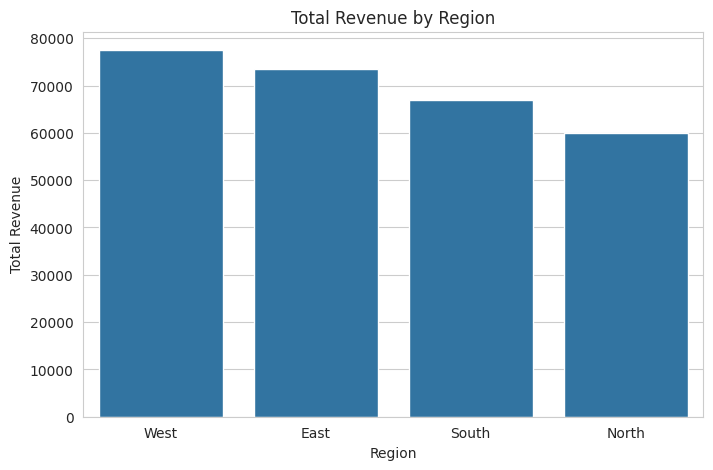

In [23]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=region_df,
    x="region",
    y="total_revenue"
)

plt.title("Total Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue")

plt.show()


 Use SQL to calculate the total revenue generated by each product and store the result in a Pandas DataFrame.

In [24]:
query = """
SELECT
    product,
    SUM(revenue) AS total_revenue
FROM sales
GROUP BY product
ORDER BY total_revenue DESC;
"""

product_df = pd.read_sql_query(query, conn)

display(product_df)


,product,total_revenue
0,Laptop,114500.0
1,Phone,93000.0
2,Tablet,70500.0


Create a bar chart showing total revenue for each product using the results obtained from SQL.

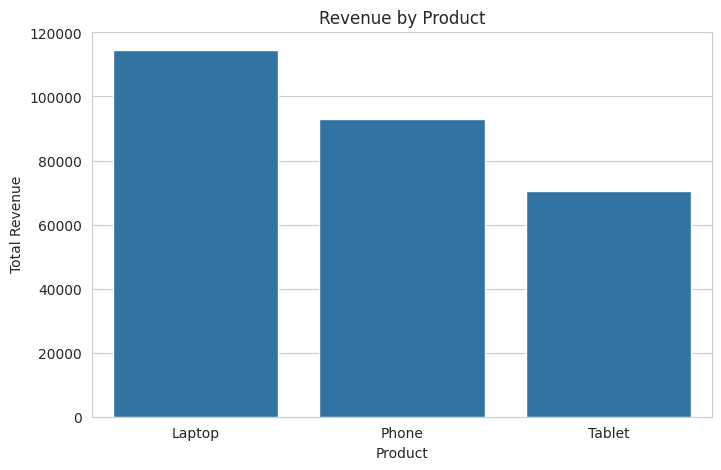

In [25]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=product_df,
    x="product",
    y="total_revenue"
)

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Total Revenue")

plt.show()


 Use SQL to retrieve monthly revenue in the original transaction order. Store the result in a DataFrame for visualization.

In [26]:
query = """
SELECT
    sale_id,
    month,
    revenue
FROM sales
ORDER BY sale_id;
"""

monthly_df = pd.read_sql_query(query, conn)

display(monthly_df)


,sale_id,month,revenue
0,1,Jan,12000.0
1,2,Feb,14500.0
2,3,Mar,17000.0
3,4,Apr,16500.0
4,5,May,20000.0
5,6,Jun,22500.0
6,7,Jul,24000.0
7,8,Aug,26000.0
8,9,Sep,28000.0
9,10,Oct,30000.0


Create a line chart showing the monthly revenue trend from January to December. Use markers to highlight individual months.

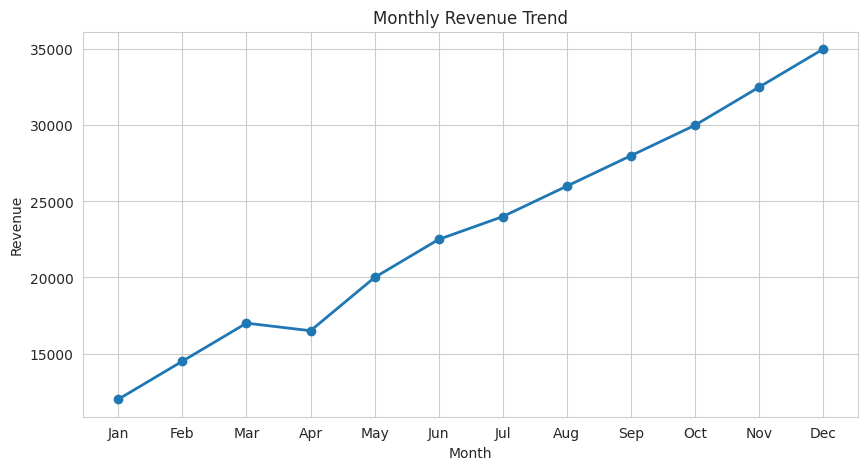

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_df["month"],
    monthly_df["revenue"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()
